# **EDA on Retail Sales Data**

import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

load dataset

In [ ]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

The dataset contains 1,000 transactions across 9 columns with no missing values and no duplicate rows

**Descriptive stats**

In [ ]:
num_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

stats = pd.DataFrame({
        "mean": df[num_cols].mean(),
        "median": df[num_cols].median(),
        "mode": df[num_cols].mode().iloc[0],
        "std": df[num_cols].std(),
    })
print("\nDescriptive Statistics:\n", stats.round(2))



Descriptive Statistics:
                   mean  median  mode     std
Age              41.39    42.0  43.0   13.68
Quantity          2.51     3.0   4.0    1.13
Price per Unit  179.89    50.0  50.0  189.68
Total Amount    456.00   135.0  50.0  560.00


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Mean spend is much higher than the median, showing the data is right-skewed by a few high-value purchases. Age is fairly balanced (mean 41.4, median 42), so no major skew there.

### Monthly and Quarterly Sales Trends

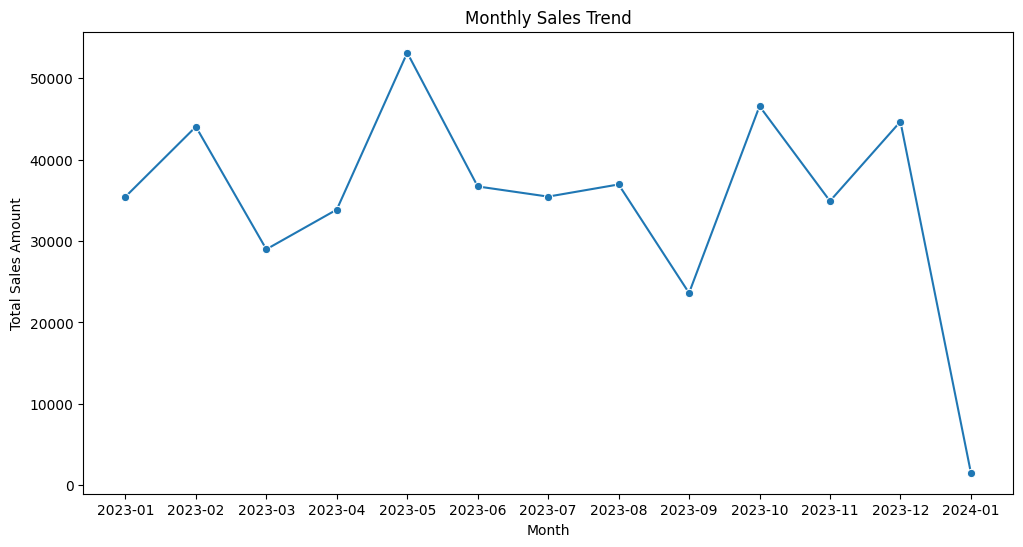

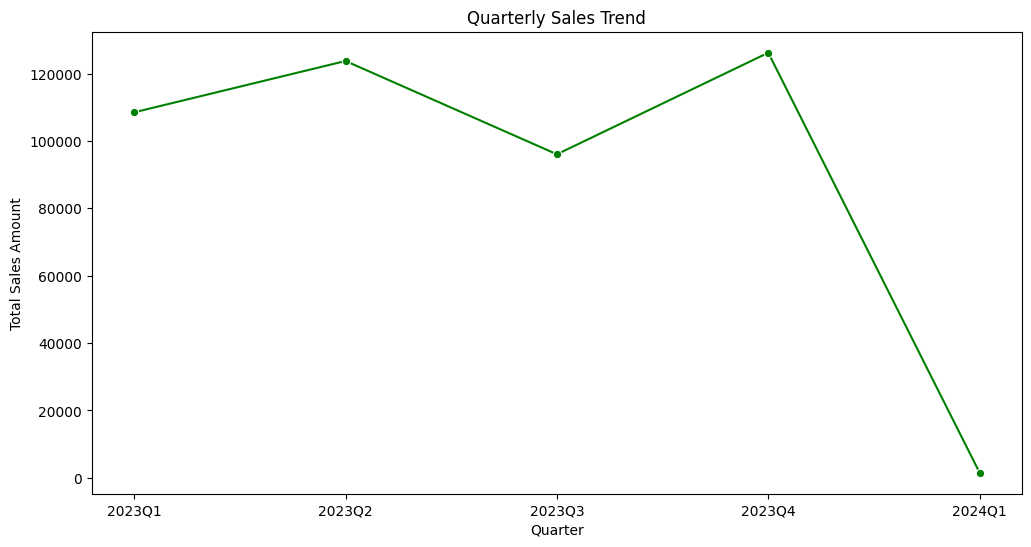

In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and quarter
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Calculate quarterly sales
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum().reset_index()
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].astype(str)

# Plotting monthly sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Total Amount', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.show()

# Plotting quarterly sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='Quarter', y='Total Amount', data=quarterly_sales, marker='o', color='green')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.show()

Sales are volatile, with May and October 2023 as clear peaks and September as the weakest month. Q4 2023 is the strongest quarter, January 2024 shows only 1 day of data, so it isn't a real drop.

# **distribution of customer age groups, gender breakdown **


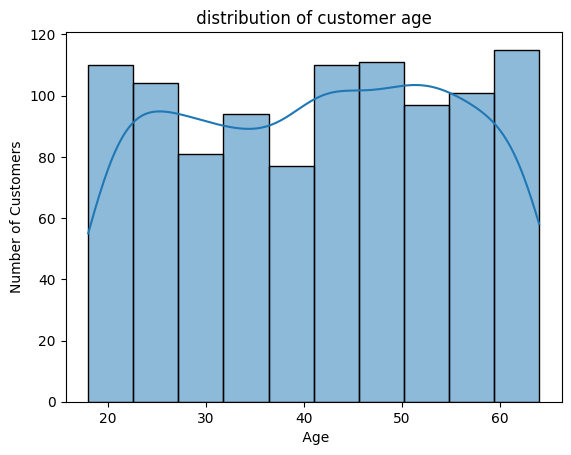

In [ ]:
sns.histplot(df["Age"],bins=10,kde=True)
plt.title(" distribution of customer age ")
plt.xlabel(" Age")
plt.ylabel("Number of Customers")
plt.show()

/tmp/ipykernel_1286/72690240.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='viridis')


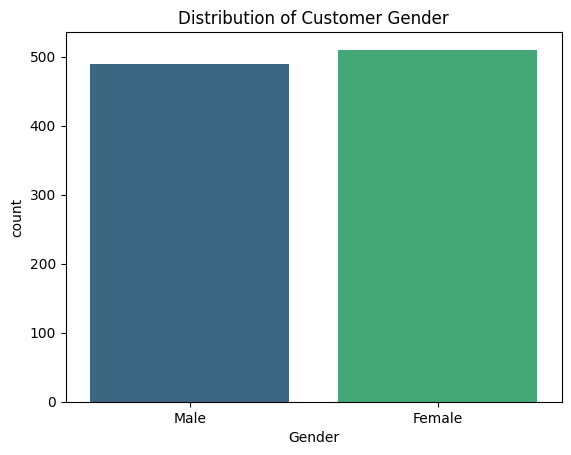

In [ ]:
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Customer Gender')
plt.show()

Customer ages are spread fairly evenly from 18 to 64, with no dominant age group. This suggests the customer base isn't concentrated around one generation.

Customers are almost evenly split by gender (51% Female, 49% Male), and so is revenue ($232,840 vs $223,160). Gender alone doesn't strongly affect total spending.

# **top 10 best-selling products; revenue by product category**

Top 10 Best-Selling Product Categories (by Total Amount):
  Product Category  Total Amount
2      Electronics        156905
1         Clothing        155580
0           Beauty        143515


/tmp/ipykernel_1286/2055510914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount', data=revenue_by_category, palette='magma')


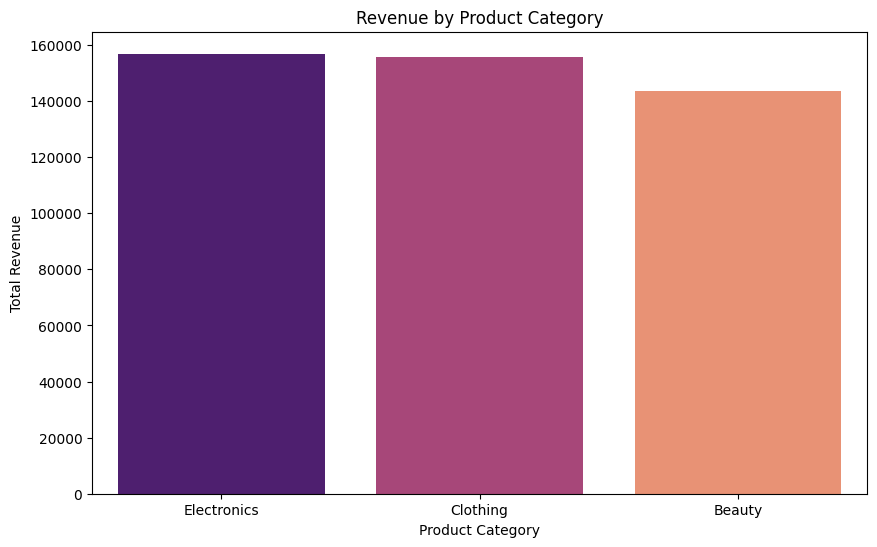

In [ ]:
# Revenue by Product Category
revenue_by_category = df.groupby('Product Category')['Total Amount'].sum().reset_index()
revenue_by_category = revenue_by_category.sort_values(by='Total Amount', ascending=False)

print("Top 10 Best-Selling Product Categories (by Total Amount):")
print(revenue_by_category.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Product Category', y='Total Amount', data=revenue_by_category, palette='magma')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.show()

/tmp/ipykernel_1286/3487193280.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax  = sns.barplot(x=Category.index,y=Category.values,palette=sns.color_palette("tab10"))
/tmp/ipykernel_1286/3487193280.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  ax  = sns.barplot(x=Category.index,y=Category.values,palette=sns.color_palette("tab10"))


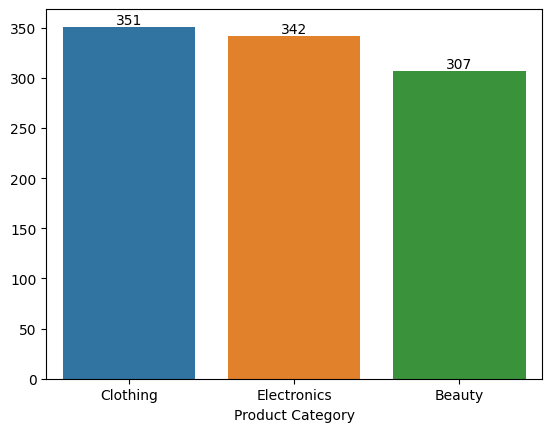

In [ ]:
Category =  df['Product Category'].value_counts()
ax  = sns.barplot(x=Category.index,y=Category.values,palette=sns.color_palette("tab10"))
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

Revenue is nearly balanced across categories — Electronics , Clothing , and Beauty. No single category dominates sales.

Heatmap:: correlation matrix between numerical variables


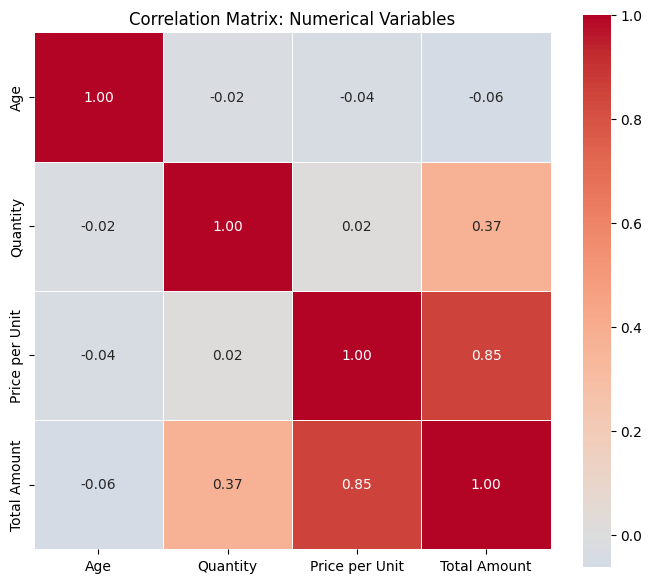

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5, square=True)
plt.title("Correlation Matrix: Numerical Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

Total Amount is strongly linked to Price per Unit (r = 0.85) and Quantity (r = 0.37), as expected. Age shows almost no correlation with spending, so it's not a useful predictor.

# Age vs. Total Amount Spent

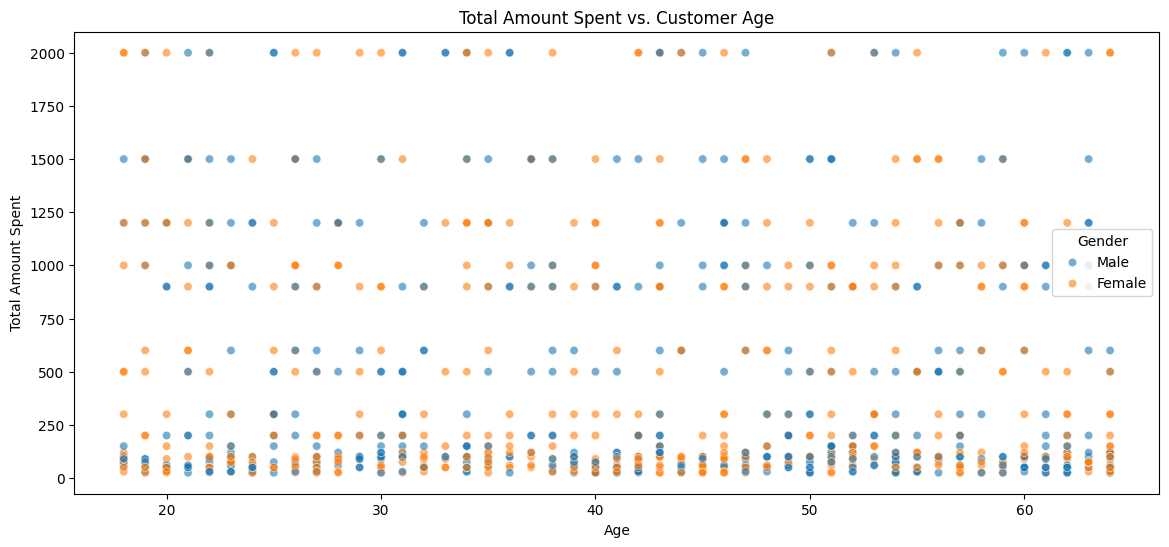

In [ ]:
plt.figure(figsize=(14, 6))
sns.scatterplot(x='Age', y='Total Amount', data=df, hue='Gender', alpha=0.6)
plt.title('Total Amount Spent vs. Customer Age')
plt.xlabel('Age')
plt.ylabel('Total Amount Spent')
plt.show()

The scatter plot confirms there's no real trend between Age and spending — high and low spenders appear at every age. This matches the near-zero correlation seen earlier.

# Total Amount by Product Category and Gender

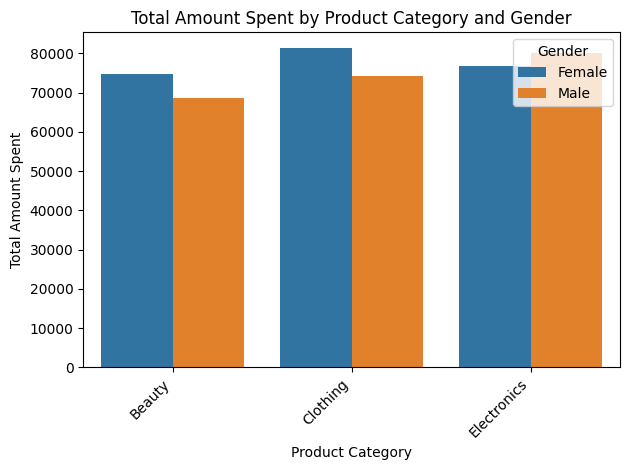

In [ ]:
gender_category_spending = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().reset_index()
sns.barplot(x='Product Category', y='Total Amount', hue='Gender', data=gender_category_spending)
plt.title('Total Amount Spent by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Females spend more on Beauty and Clothing, while Males spend more on Electronics. This category-level split is hidden in the overall gender totals.

# Distribution of Quantity per Transaction

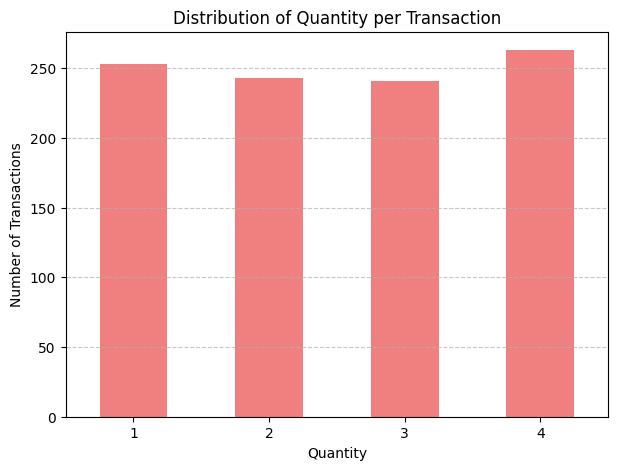

In [ ]:
plt.figure(figsize=(7, 5))
df['Quantity'].value_counts().sort_index().plot(kind='bar', color='lightcoral')
plt.title('Distribution of Quantity per Transaction')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Quantities per transaction (1–4 units) are almost equally distributed, with no strong preference for smaller or larger orders. This is unusual for typical retail data.

# Conclusion & Recommendations

* **Boost Peak Seasons,
Fix Dips**: May, October, and Q4 are our strongest periods — let's push promotions and stock up ahead of them. September is weak, so we should dig into why and find ways to lift it.
* **Gender-Specific Marketing**: Women spend more on Beauty and Clothing, men lean toward Electronics. Targeting promotions by gender and category instead of running broad campaigns should work better.
* **Encourage Bigger Purchases**: Order sizes stay stuck at 1-4 items. Bundles or deals like "buy 2, get 1 free" could push customers to buy more per visit.

